In [ ]:
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


def build_upset_visualization(
    dataframe,
    columns=None,
    missing_limit=3,
    selection_method="above_median",
    top_combinations=20,
    minimum_count=1,
    layout="horizontal",
    dim_opacity=0.30,
    guide_line_opacity=0.18,
    heading="UpSet plot"
):
    """

    Аргументы
    ---------
    dataframe : pandas.DataFrame
        Исходная таблица данных.

    columns : list[str] | None, default=None
        Перечень столбцов для анализа.
        При значении None выбираются все числовые столбцы:
        int, float и bool.

    missing_limit : int, default=3
        Порог пропусков: если NaN в столбце превышает это значение,
        строки с NaN включаются в множество данного столбца.

        Пример: missing_limit=3 означает включение NaN только
        при 4 и более пропусках в столбце.

    selection_method : str, default="above_median"
        Критерий включения строки в множество:
        - "above_median": значение строго выше медианы;
        - "above_mean": значение строго выше среднего;
        - "top_quartile": значение не ниже 75-го перцентиля;
        - "nonzero": значение отлично от нуля.

    top_combinations : int, default=20
        Наибольшее количество пересечений для отображения.
        При большом числе столбцов рекомендуется 15-30.

    minimum_count : int, default=1
        Наименьшее количество строк в пересечении.
        Более редкие комбинации отбрасываются.

    layout : str, default="horizontal"
        - "horizontal": классическая раскладка:
          размеры пересечений вверху, матрица внизу,
          столбцы расположены по строкам.

        - "vertical": повёрнутая раскладка:
          размеры множеств вверху, матрица слева,
          размеры пересечений справа,
          столбцы расположены по колонкам.

    dim_opacity : float, default=0.30
        Прозрачность неактивных серых точек.
        0 = полностью прозрачные, 1 = непрозрачные.

    guide_line_opacity : float, default=0.18
        Прозрачность фоновых направляющих.

    heading : str, default="UpSet plot"
        Заголовок диаграммы.

    Возвращает
    ----------
    figure : matplotlib.figure.Figure

    output : dict
        Словарь с данными построения:
        - columns;
        - column_sets;
        - column_sizes;
        - missing_counts;
        - cutoff_values;
        - combinations;
        - layout.
    """

    # ============================================================
    # Шаг 1. Валидация входных параметров
    # ============================================================
    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError("dataframe должен быть экземпляром pandas.DataFrame.")

    if layout not in {"horizontal", "vertical"}:
        raise ValueError(
            "layout принимает только 'horizontal' или 'vertical'."
        )

    if selection_method not in {
        "above_median",
        "above_mean",
        "top_quartile",
        "nonzero"
    }:
        raise ValueError(
            "selection_method должен быть одним из: "
            "'above_median', 'above_mean', "
            "'top_quartile', 'nonzero'."
        )

    if missing_limit < 0:
        raise ValueError("missing_limit должен быть >= 0.")

    if top_combinations < 1:
        raise ValueError("top_combinations должен быть >= 1.")

    if minimum_count < 1:
        raise ValueError("minimum_count должен быть >= 1.")

    if not 0 <= dim_opacity <= 1:
        raise ValueError("dim_opacity должен быть в диапазоне [0, 1].")

    if not 0 <= guide_line_opacity <= 1:
        raise ValueError(
            "guide_line_opacity должен быть в диапазоне [0, 1]."
        )

    # ============================================================
    # Шаг 2. Автоопределение числовых столбцов
    # ============================================================
    if columns is None:
        columns = dataframe.select_dtypes(
            include=[np.number, "bool"]
        ).columns.tolist()

    columns = list(columns)

    if len(columns) == 0:
        raise ValueError("В dataframe не обнаружено числовых столбцов.")

    absent_columns = [
        col
        for col in columns
        if col not in dataframe.columns
    ]

    if absent_columns:
        raise ValueError(
            f"В dataframe отсутствуют столбцы: {absent_columns}"
        )

    # ============================================================
    # Шаг 3. Построение множеств индексов строк для каждого столбца
    # ============================================================
    column_sets = {}
    missing_counts = {}
    cutoff_values = {}

    for col in columns:
        # Приведение к числовому типу.
        # Невалидные значения превращаются в NaN.
        series = pd.to_numeric(dataframe[col], errors="coerce")

        # Бесконечности также рассматриваются как пропуски.
        series = series.replace([np.inf, -np.inf], np.nan)

        missing_count = int(series.isna().sum())
        missing_counts[col] = missing_count

        valid_series = series.dropna()

        # Случай, когда весь столбец состоит из NaN.
        if len(valid_series) == 0:
            cutoff_values[col] = None

            if missing_count > missing_limit:
                column_sets[col] = set(
                    dataframe.index[series.isna()]
                )

            continue

        # --------------------------------------------------------
        # Определение критерия включения строки в множество.
        # --------------------------------------------------------
        if selection_method == "above_median":
            cutoff = float(valid_series.median())
            inclusion_mask = series > cutoff

        elif selection_method == "above_mean":
            cutoff = float(valid_series.mean())
            inclusion_mask = series > cutoff

        elif selection_method == "top_quartile":
            cutoff = float(valid_series.quantile(0.75))
            inclusion_mask = series >= cutoff

        else:  # selection_method == "nonzero"
            cutoff = 0.0
            inclusion_mask = (series != 0) & series.notna()

        cutoff_values[col] = cutoff

        # Индексы строк, удовлетворяющих числовому условию.
        row_indices = set(dataframe.index[inclusion_mask])

        # Если пропусков больше порога — NaN-строки включаются
        # в множество данного столбца.
        if missing_count > missing_limit:
            row_indices.update(dataframe.index[series.isna()])

        # Пустые множества игнорируются.
        if len(row_indices) > 0:
            column_sets[col] = row_indices

    if len(column_sets) == 0:
        raise ValueError(
            "Не удалось построить непустые множества для столбцов."
        )

    active_columns = list(column_sets.keys())

    # ============================================================
    # Шаг 4. Вычисление размеров множеств и сортировка столбцов
    # ============================================================
    column_sizes_map = {
        col: len(column_sets[col])
        for col in active_columns
    }

    active_columns.sort(
            key=lambda col: (
                column_sizes_map[col],
                str(col)
            ),
            reverse=True
        )

    # ============================================================
    # Шаг 5. Извлечение только реально встречающихся пересечений
    #
    # Перебор 2^N комбинаций не производится.
    # Анализируются фактические строки данных.
    # ============================================================
    all_row_indices = set().union(*column_sets.values())

    pattern_frequency = Counter()
    pattern_debut = {}

    for position, row_idx in enumerate(all_row_indices):
        signature = tuple(
            row_idx in column_sets[col]
            for col in active_columns
        )

        if not any(signature):
            continue

        pattern_frequency[signature] += 1

        if signature not in pattern_debut:
            pattern_debut[signature] = position

    combinations = []

    for signature, frequency in pattern_frequency.items():
        if frequency < minimum_count:
            continue

        contributing_columns = [
            col
            for col, is_present in zip(active_columns, signature)
            if is_present
        ]

        combinations.append({
            "signature": signature,
            "columns": contributing_columns,
            "frequency": frequency,
            "degree": sum(signature),
            "debut": pattern_debut[signature]
        })

    if len(combinations) == 0:
        raise ValueError(
            "После применения minimum_count пересечений не осталось."
        )

    # ============================================================
    # Шаг 6. Упорядочивание пересечений
    # ============================================================
    combinations.sort(
            key=lambda entry: (
                entry["frequency"],
                entry["degree"],
                tuple(entry["columns"])
            ),
            reverse=True
        )

    # Оставляем лишь top_combinations наиболее значимых.
    combinations = combinations[:top_combinations]

    # ============================================================
    # Шаг 7. Подготовка данных для отрисовки
    # ============================================================
    num_columns = len(active_columns)
    num_combinations = len(combinations)

    column_sizes = [
        column_sizes_map[col]
        for col in active_columns
    ]

    combination_sizes = [
        entry["frequency"]
        for entry in combinations
    ]

    # Цветовая палитра: тёмно-фиолетовый как основной.
    primary_color = "#4A1A6B"
    secondary_color = "#B0B0B0"
    guide_color = "#AFAFAF"
    bar_color = "#4A1A6B"

    # ============================================================
    # Шаг 8. Горизонтальная раскладка
    #
    # Верх: размеры пересечений.
    # Лево: размеры множеств.
    # Низ-право: матрица.
    # ============================================================
    if layout == "horizontal":
        figure_width = max(11, 0.72 * num_combinations + 5.5)
        figure_height = max(6.5, 0.52 * num_columns + 4.5)

        figure = plt.figure(figsize=(figure_width, figure_height))

        grid = GridSpec(
            nrows=2,
            ncols=2,
            width_ratios=[2.7, 7.0],
            height_ratios=[3.2, max(2.7, num_columns * 0.52)],
            wspace=0.08,
            hspace=0.08
        )

        ax_blank = figure.add_subplot(grid[0, 0])
        ax_top = figure.add_subplot(grid[0, 1])
        ax_left = figure.add_subplot(grid[1, 0])
        ax_matrix = figure.add_subplot(grid[1, 1])

        ax_blank.axis("off")

        x_coords = np.arange(num_combinations)
        y_coords = np.arange(num_columns)

        # --------------------------------------------------------
        # Верхняя гистограмма: размеры пересечений.
        # --------------------------------------------------------
        top_bars = ax_top.bar(
            x_coords,
            combination_sizes,
            width=0.65,
            color=primary_color
        )

        for bar, value in zip(top_bars, combination_sizes):
            ax_top.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                str(value),
                ha="center",
                va="bottom",
                fontsize=9
            )

        ax_top.set_xlim(-0.7, num_combinations - 0.3)
        ax_top.set_xticks([])
        ax_top.set_ylabel("Размер\nпересечения")
        ax_top.grid(axis="y", alpha=0.20)

        ax_top.spines["top"].set_visible(False)
        ax_top.spines["right"].set_visible(False)

        # --------------------------------------------------------
        # Левая гистограмма: размеры множеств.
        # --------------------------------------------------------
        flipped_columns = list(reversed(active_columns))
        flipped_sizes = list(reversed(column_sizes))
        y_left = np.arange(num_columns)

        left_bars = ax_left.barh(
            y_left,
            flipped_sizes,
            height=0.55,
            color=bar_color
        )

        for bar, value in zip(left_bars, flipped_sizes):
            ax_left.text(
                bar.get_width(),
                bar.get_y() + bar.get_height() / 2,
                f" {value}",
                ha="left",
                va="center",
                fontsize=9
            )

        ax_left.set_yticks(y_left)
        ax_left.set_yticklabels(flipped_columns, fontsize=9)
        ax_left.set_xlabel("Размер множества")
        ax_left.invert_xaxis()
        ax_left.grid(axis="x", alpha=0.20)

        ax_left.spines["top"].set_visible(False)
        ax_left.spines["left"].set_visible(False)
        ax_left.spines["right"].set_visible(False)

        # --------------------------------------------------------
        # Фоновые серые полосы.
        # --------------------------------------------------------
        for y in y_coords:
            if y % 2 == 0:
                ax_matrix.axhspan(
                    y - 0.5,
                    y + 0.5,
                    facecolor="#F5F5F5",
                    alpha=0.6,
                    zorder=0
                )

        # --------------------------------------------------------
        # Серые неактивные точки.
        # --------------------------------------------------------
        for x in x_coords:
            ax_matrix.scatter(
                np.full(num_columns, x),
                y_coords,
                s=58,
                color=secondary_color,
                alpha=dim_opacity,
                zorder=1
            )

        # --------------------------------------------------------
        # Фиолетовые активные точки и вертикальные линии.
        # --------------------------------------------------------
        for x, entry in enumerate(combinations):
            active_rows = [
                row
                for row, is_present in enumerate(entry["signature"])
                if is_present
            ]

            if len(active_rows) >= 2:
                ax_matrix.plot(
                    [x, x],
                    [min(active_rows), max(active_rows)],
                    color=primary_color,
                    linewidth=2.3,
                    zorder=2
                )

            ax_matrix.scatter(
                np.full(len(active_rows), x),
                active_rows,
                s=65,
                color=primary_color,
                zorder=3
            )

        ax_matrix.set_xlim(-0.7, num_combinations - 0.3)
        ax_matrix.set_ylim(-0.7, num_columns - 0.3)

        ax_matrix.set_xticks(x_coords)
        ax_matrix.set_xticklabels(
            [str(i + 1) for i in range(num_combinations)],
            fontsize=8
        )

        ax_matrix.set_yticks(y_coords)
        ax_matrix.set_yticklabels([])

        ax_matrix.set_xlabel("Пересечения")

        ax_matrix.spines["top"].set_visible(False)
        ax_matrix.spines["right"].set_visible(False)
        ax_matrix.spines["left"].set_visible(False)

    # ============================================================
    # Шаг 9. Вертикальная раскладка
    #
    # Верх: размеры множеств.
    # Лево: матрица.
    # Право: размеры пересечений.
    # ============================================================
    else:
        figure_width = max(10, 0.90 * num_columns + 5.8)
        figure_height = max(9, 0.52 * num_combinations + 6.5)

        figure = plt.figure(figsize=(figure_width, figure_height))

        grid = GridSpec(
            nrows=2,
            ncols=2,
            width_ratios=[max(4.5, num_columns * 0.85), 3.2],
            height_ratios=[4.0, max(4.0, num_combinations * 0.40)],
            wspace=0.10,
            hspace=0.14
        )

        ax_sets = figure.add_subplot(grid[0, 0])
        ax_blank = figure.add_subplot(grid[0, 1])
        ax_matrix = figure.add_subplot(grid[1, 0])
        ax_right = figure.add_subplot(grid[1, 1])

        ax_blank.axis("off")

        x_coords = np.arange(num_columns)
        y_coords = np.arange(num_combinations)

        # --------------------------------------------------------
        # Верхняя гистограмма: размеры множеств.
        # --------------------------------------------------------
        set_bars = ax_sets.bar(
            x_coords,
            column_sizes,
            width=0.55,
            color=bar_color
        )

        for bar, value in zip(set_bars, column_sizes):
            ax_sets.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                str(value),
                ha="center",
                va="bottom",
                fontsize=9
            )

        ax_sets.set_xlim(-0.7, num_columns - 0.3)
        ax_sets.set_ylabel("Размер множества")
        ax_sets.grid(axis="y", alpha=0.20)

        # X-подписи не используются: при длинных именах
        # они обрезаются между subplots.
        ax_sets.set_xticks([])

        ax_sets.spines["top"].set_visible(False)
        ax_sets.spines["right"].set_visible(False)

        # --------------------------------------------------------
        # Фоновые серые вертикальные полосы.
        # Один столбец = один признак.
        # --------------------------------------------------------
        for x in x_coords:
            if x % 2 == 0:
                ax_matrix.axvspan(
                    x - 0.5,
                    x + 0.5,
                    facecolor="#F5F5F5",
                    alpha=0.6,
                    zorder=0
                )

        # --------------------------------------------------------
        # Серые неактивные точки.
        # --------------------------------------------------------
        for y in y_coords:
            ax_matrix.scatter(
                x_coords,
                np.full(num_columns, y),
                s=58,
                color=secondary_color,
                alpha=dim_opacity,
                zorder=1
            )

        # --------------------------------------------------------
        # Фиолетовые активные точки и горизонтальные линии.
        # --------------------------------------------------------
        for y, entry in enumerate(combinations):
            active_cols = [
                col
                for col, is_present in enumerate(entry["signature"])
                if is_present
            ]

            if len(active_cols) >= 2:
                ax_matrix.plot(
                    [min(active_cols), max(active_cols)],
                    [y, y],
                    color=primary_color,
                    linewidth=2.3,
                    zorder=2
                )

            ax_matrix.scatter(
                active_cols,
                np.full(len(active_cols), y),
                s=65,
                color=primary_color,
                zorder=3
            )

        ax_matrix.set_xlim(-0.7, num_columns - 0.3)
        ax_matrix.set_ylim(-0.7, num_combinations - 0.3)

        ax_matrix.set_xticks(x_coords)
        ax_matrix.set_xticklabels(
            active_columns,
            rotation=45,
            ha="right",
            fontsize=9
        )

        ax_matrix.set_yticks(y_coords)
        ax_matrix.set_yticklabels(
            [str(i + 1) for i in range(num_combinations)],
            fontsize=8
        )

        ax_matrix.set_xlabel("Признаки")
        ax_matrix.set_ylabel("Пересечения")

        ax_matrix.spines["top"].set_visible(False)
        ax_matrix.spines["right"].set_visible(False)

        # --------------------------------------------------------
        # Правая гистограмма: размеры пересечений.
        # --------------------------------------------------------
        right_bars = ax_right.barh(
            y_coords,
            combination_sizes,
            height=0.65,
            color=primary_color
        )

        for bar, value in zip(right_bars, combination_sizes):
            ax_right.text(
                bar.get_width(),
                bar.get_y() + bar.get_height() / 2,
                f" {value}",
                ha="left",
                va="center",
                fontsize=9
            )

        ax_right.set_ylim(-0.7, num_combinations - 0.3)
        ax_right.set_yticks([])
        ax_right.set_xlabel("Размер\nпересечения")
        ax_right.grid(axis="x", alpha=0.20)

        ax_right.spines["top"].set_visible(False)
        ax_right.spines["right"].set_visible(False)
        ax_right.spines["left"].set_visible(False)

    # ============================================================
    # Шаг 10. Итоговое оформление фигуры
    # ============================================================
    figure.suptitle(heading, fontsize=14, y=0.995)

    if layout == "horizontal":
        figure.subplots_adjust(
            top=0.90,
            bottom=0.12,
            left=0.10,
            right=0.97
        )
    else:
        figure.subplots_adjust(
            top=0.89,
            bottom=0.14,
            left=0.10,
            right=0.97
        )

    output = {
        "columns": active_columns,
        "column_sets": column_sets,
        "column_sizes": {
            col: column_sizes_map[col]
            for col in active_columns
        },
        "missing_counts": {
            col: missing_counts[col]
            for col in active_columns
        },
        "cutoff_values": {
            col: cutoff_values[col]
            for col in active_columns
        },
        "combinations": combinations,
        "layout": layout
    }

    return figure, output

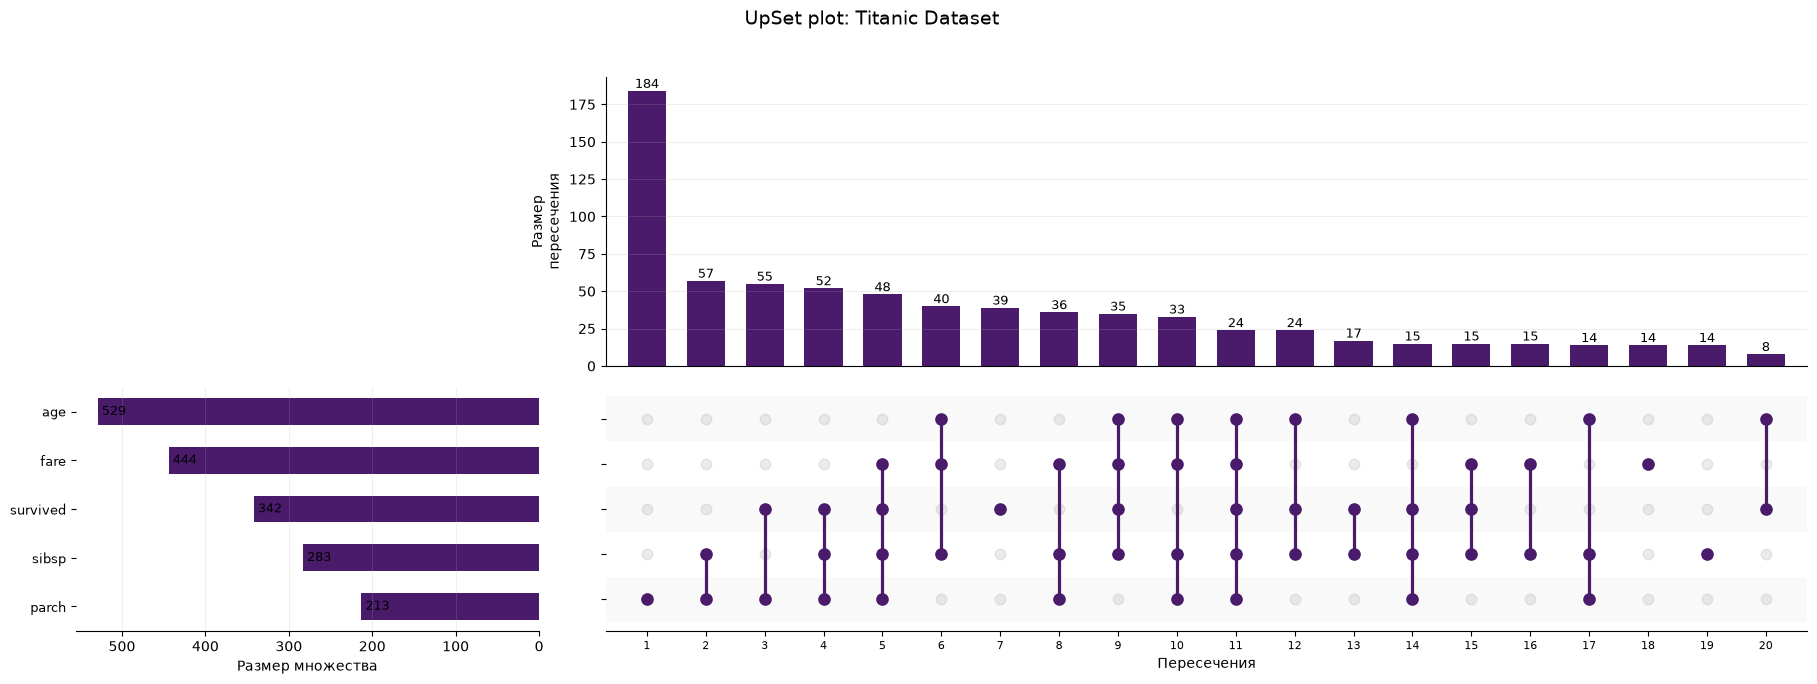

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/home/julia/code/NSU_AI-Robotics/tsr/archive/Titanic.csv")

df = df.drop(columns=["Unnamed: 0"])

fig, result = build_upset_visualization(
    dataframe=df,
    columns=None,
    missing_limit=3,
    selection_method="above_median",
    top_combinations=20,
    minimum_count=2,

    # Серые точки и линии на фоне:
    dim_opacity=0.25,
    guide_line_opacity=0.16,

    # "horizontal" — второй рисунок;
    # "vertical" — первый рисунок.
    layout="horizontal",

    heading="UpSet plot: Titanic Dataset"
)

plt.show()

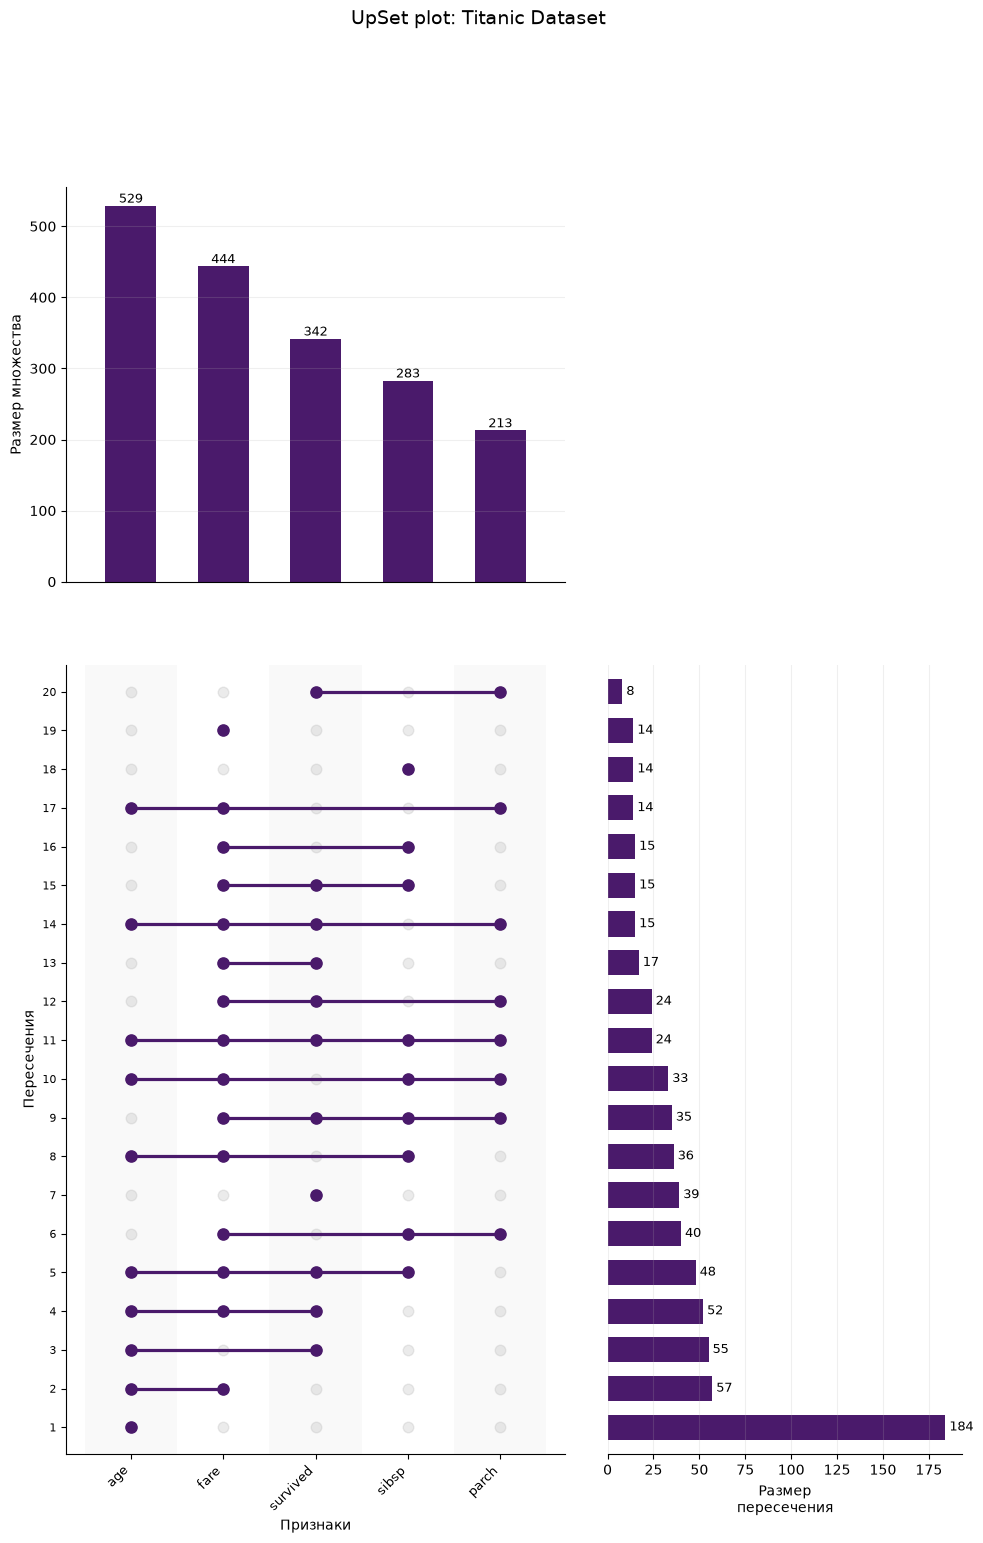

In [ ]:
fig, result = build_upset_visualization(
    dataframe=df,
    columns=None,
    missing_limit=3,
    selection_method="above_median",
    top_combinations=20,
    minimum_count=2,

    # Серые точки и линии на фоне:
    dim_opacity=0.25,
    guide_line_opacity=0.16,

    layout="vertical",

    heading="UpSet plot: Titanic Dataset"
)

plt.show()


# TODO: Спросить норм ли то максимум снизу